# Validação rápida — `trending_by_time.csv`

Sprint 12 · Sterling & Draper · dashboard no Tableau Public

Objetivo: olhar os dados como simples análise prévia antes do Tableau e ter **números de referência** para conferir cada planilha do dashboard, evitando falta de entendimento quanto aos números.
Nada aqui vai para o dashboard; é só minha visualização e norte.

**Lembrete:** `videos_count` = vídeos na seção de tendências **naquele dia**. Somar dias dá *vídeo-dias em alta*, não vídeos únicos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:,.1f}'.format)
plt.rcParams['figure.figsize'] = (12, 4)

df = pd.read_csv('../data/trending_by_time.csv', parse_dates=['trending_date'])
df.head()

,record_id,region,trending_date,category_title,videos_count
0,1,France,2017-11-14,Autos & Vehicles,8
1,2,France,2017-11-15,Autos & Vehicles,2
2,3,France,2017-11-16,Autos & Vehicles,6
3,4,France,2017-11-17,Autos & Vehicles,8
4,5,France,2017-11-18,Autos & Vehicles,4


## 1. Perfil

In [2]:
print(df.shape)
print(df.dtypes, '\n')
print('nulos:', df.isna().sum().sum())
print('record_id único:', df['record_id'].is_unique)
print('duplicados (região, data, categoria):', df.duplicated(['region', 'trending_date', 'category_title']).sum())
print('horas diferentes de 00:00:', (df['trending_date'].dt.normalize() != df['trending_date']).sum())
print('período:', df['trending_date'].min().date(), '→', df['trending_date'].max().date())
df[['region', 'category_title']].nunique()

(12343, 5)
record_id                  int64
region                    object
trending_date     datetime64[ns]
category_title            object
videos_count               int64
dtype: object 

nulos: 0
record_id único: True
duplicados (região, data, categoria): 0
horas diferentes de 00:00: 0
período: 2017-11-14 → 2018-06-14


region             5
category_title    18
dtype: int64

In [3]:
df['videos_count'].describe()

count   12,343.0
mean        27.5
std         29.8
min          2.0
25%          8.0
50%         18.0
75%         36.0
max        220.0
Name: videos_count, dtype: float64

## 2. Cobertura no tempo (armadilhas 2 e 3)

In [14]:
cobertura = df.groupby('region')['trending_date'].agg(inicio='min', fim='max', dias='nunique')
display(cobertura)

,inicio,fim,dias
region,,,
France,2017-11-14,2018-06-14,205
India,2017-11-14,2018-06-14,205
Japan,2018-02-07,2018-06-14,122
Russia,2017-11-14,2018-06-14,205
United States,2017-11-14,2018-06-14,205


In [5]:
todas_datas = pd.date_range(df['trending_date'].min(), df['trending_date'].max(), freq='D')
faltando = todas_datas.difference(df['trending_date'].unique())
print(f'{len(faltando)} dias sem nenhum dado:', [d.date().isoformat() for d in faltando])

8 dias sem nenhum dado: ['2018-01-10', '2018-01-11', '2018-04-08', '2018-04-09', '2018-04-10', '2018-04-11', '2018-04-12', '2018-04-13']


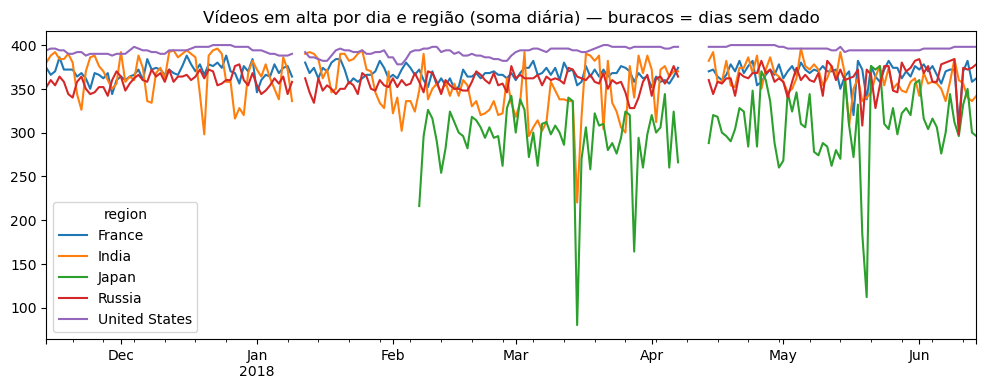

In [6]:
diario = df.pivot_table(index='trending_date', columns='region', values='videos_count', aggfunc='sum')
diario.reindex(todas_datas).plot(title='Vídeos em alta por dia e região (soma diária) — buracos = dias sem dado')
plt.show()

## 3. P1 — Quais categorias estão em alta com mais frequência?

Período inteiro e "semana passada" (assumida como os últimos 7 dias do dado: **2018-06-08 a 2018-06-14**).

In [7]:
fim = df['trending_date'].max()
semana = df[df['trending_date'] > fim - pd.Timedelta(days=7)]
print('semana usada:', semana['trending_date'].min().date(), '→', semana['trending_date'].max().date())

def ranking(d):
    s = d.groupby('category_title')['videos_count'].sum().sort_values(ascending=False)
    return pd.DataFrame({'videos': s, 'pct': s / s.sum() * 100})

p1 = ranking(df).join(ranking(semana), rsuffix='_semana')
p1

semana usada: 2018-06-08 → 2018-06-14


,videos,pct,videos_semana,pct_semana
category_title,,,,
Entertainment,95008,27.9,"3,854.0",30.6
People & Blogs,44700,13.1,"1,396.0",11.1
Music,34390,10.1,"1,518.0",12.1
News & Politics,34202,10.1,778.0,6.2
Comedy,29470,8.7,"1,142.0",9.1
Sports,20966,6.2,766.0,6.1
Howto & Style,20124,5.9,688.0,5.5
Film & Animation,19562,5.8,850.0,6.8
Science & Technology,9932,2.9,238.0,1.9


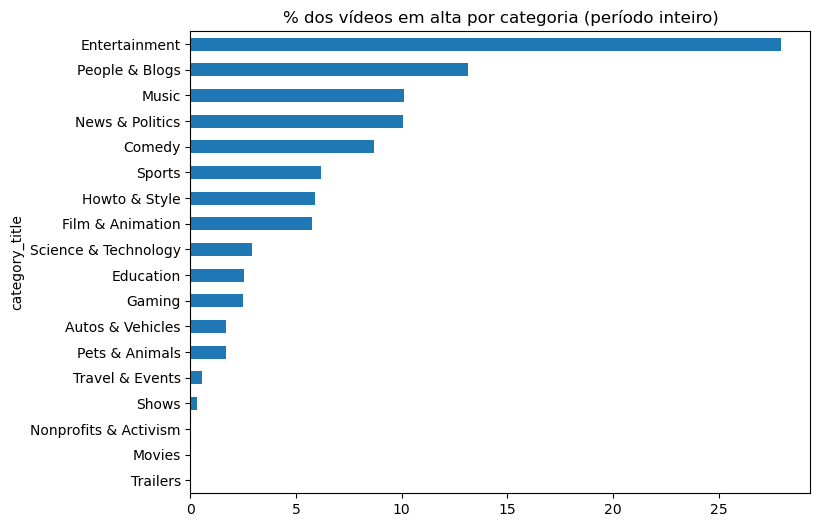

In [8]:
p1['pct'].sort_values().plot.barh(figsize=(8, 6), title='% dos vídeos em alta por categoria (período inteiro)')
plt.show()

## 4. P2 — Como se distribuem entre as regiões?

Três leituras: período inteiro (o que a pizza mostra sem filtro), período comum (a partir de 2018-02-07, quando o Japão entra) e média diária.

In [9]:
inicio_comum = cobertura['inicio'].max()
comum = df[df['trending_date'] >= inicio_comum]

total = df.groupby('region')['videos_count'].sum()
p2 = pd.DataFrame({
    'pct_periodo_inteiro': total / total.sum() * 100,
    'pct_periodo_comum': comum.groupby('region')['videos_count'].sum().pipe(lambda s: s / s.sum() * 100),
    'media_diaria': total / cobertura['dias'],
}).sort_values('pct_periodo_inteiro', ascending=False)
print('período comum a partir de', inicio_comum.date())
p2

período comum a partir de 2018-02-07


,pct_periodo_inteiro,pct_periodo_comum,media_diaria
region,,,
United States,23.8,22.2,393.9
France,22.2,20.6,367.8
Russia,21.7,20.3,359.5
India,21.6,19.8,357.9
Japan,10.8,17.0,301.3


## 5. P3 — Categorias populares nos EUA × resto

In [10]:
share = (df.assign(grupo=df['region'].where(df['region'] == 'United States', 'Outros países'))
           .pivot_table(index='category_title', columns='grupo', values='videos_count', aggfunc='sum', fill_value=0))
share = share / share.sum() * 100
share['diferenca_pp'] = share['United States'] - share['Outros países']
share.sort_values('United States', ascending=False)

grupo,Outros países,United States,diferenca_pp
category_title,,,
Entertainment,29.1,24.3,-4.8
Music,8.3,15.9,7.6
Howto & Style,4.6,10.3,5.7
Comedy,8.7,8.5,-0.2
People & Blogs,14.9,7.6,-7.3
News & Politics,11.3,6.0,-5.4
Science & Technology,2.0,5.8,3.8
Film & Animation,5.7,5.8,0.1
Sports,6.4,5.3,-1.2


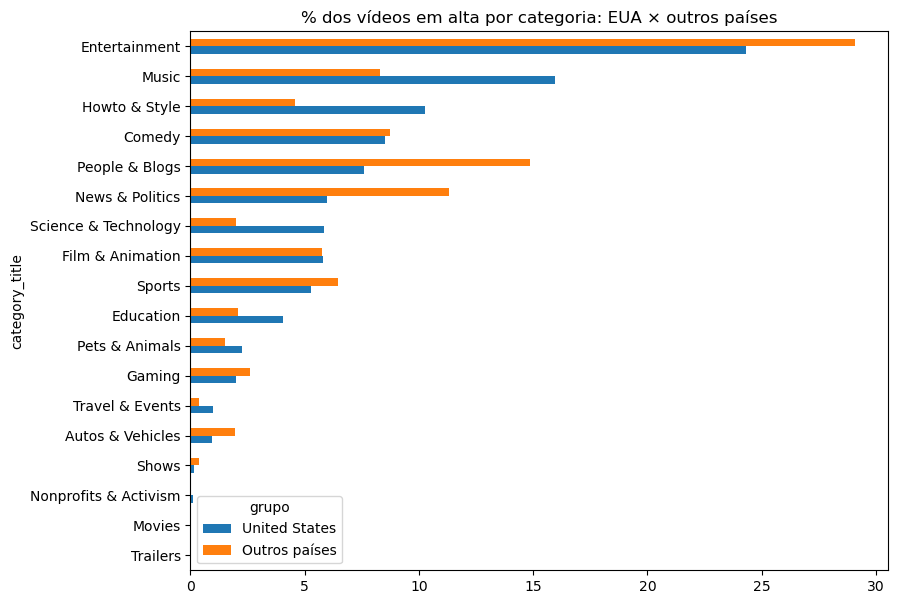

In [11]:
share.sort_values('United States')[['United States', 'Outros países']].plot.barh(
    figsize=(9, 7), title='% dos vídeos em alta por categoria: EUA × outros países')
plt.show()

## 6. Gabarito da tabela de realce (Tableau: região em colunas, categoria em linhas)

In [12]:
tabela = df.pivot_table(index='category_title', columns='region', values='videos_count', aggfunc='sum', fill_value=0)
tabela.style.background_gradient(cmap='Blues', axis=None).format('{:,.0f}')

region,France,India,Japan,Russia,United States
category_title,,,,,
Autos & Vehicles,"1,220",138,538,"3,116",758
Comedy,"8,446","6,814","1,372","5,968","6,870"
Education,"1,480","2,360",212,"1,326","3,284"
Entertainment,"19,020","32,924","11,734","11,692","19,638"
Film & Animation,"3,768","3,298","2,140","5,676","4,680"
Gaming,"2,786",132,"1,834","2,050","1,606"
Howto & Style,"4,668","1,674","1,574","3,928","8,280"
Movies,22,32,0,2,0
Music,"7,658","7,714","2,480","3,664","12,874"


In [13]:
print('total geral de videos_count:', f"{df['videos_count'].sum():,}")

total geral de videos_count: 339,990


## Anotações para o Tableau

- Conferir o **total geral** e 2–3 células da tabela acima contra a tabela de realce.
- Pizza sem filtro deve bater com `pct_periodo_inteiro`; com filtro de data a partir de 2018-02-07, com `pct_periodo_comum`.
- Gráfico de %: o topo da área tem que ficar reto em 100%.